# 1. Introduction to Edge Detection

Edge detection is a fundamental technique in **Digital Image Processing** used to identify points in an image where the pixel intensity changes rapidly. These points usually correspond to the boundaries of objects within the image.

In digital images, edge detection is commonly performed using **gradient operators**, which measure the rate of intensity change in both the horizontal and vertical directions.

For a two-dimensional image $I(x, y)$, the gradient magnitude is defined as:

$$
|\nabla I| =
\sqrt{
\left(\frac{\partial I}{\partial x}\right)^2
+
\left(\frac{\partial I}{\partial y}\right)^2
}
$$

where:

- $\frac{\partial I}{\partial x}$ represents the intensity change along the **x-axis** (horizontal direction).
- $\frac{\partial I}{\partial y}$ represents the intensity change along the **y-axis** (vertical direction).

The gradient magnitude indicates the strength of an edge:

- **Large gradient values** → Strong edges (sharp intensity changes)
- **Small gradient values** → Smooth or flat regions (little intensity change)

Gradient-based edge detection forms the basis of many popular algorithms such as **Sobel**, **Prewitt**, **Roberts**, and **Canny** edge detectors.

In [1]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# 2. Reading the Image

The image is loaded in grayscale so that edge detection works on intensity values rather than color channels.

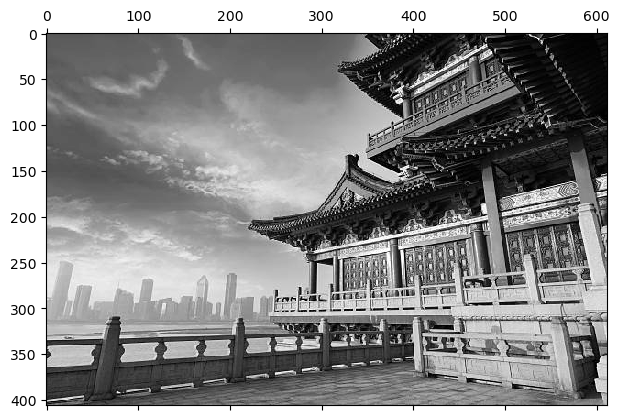

In [2]:
img = cv2.imread('input3.jpg', cv2.IMREAD_GRAYSCALE)
plt.matshow(img, cmap='gray')

# 3.Sobel Operator

The **Sobel operator** estimates image gradients in both the **horizontal (x)** and **vertical (y)** directions by convolving the image with two small \(3 \times 3\) kernels. It is one of the most widely used edge detection methods because it is simple and effective.

The Sobel operator computes two gradients:

- \(G_x\): Gradient in the horizontal direction (detects vertical edges)
- \(G_y\): Gradient in the vertical direction (detects horizontal edges)

The gradient magnitude is calculated as:

$$
G = \sqrt{G_x^2 + G_y^2}
$$

where:

- \(G_x\) is the response of the Sobel **X** kernel.
- \(G_y\) is the response of the Sobel **Y** kernel.

A larger gradient magnitude indicates a stronger edge, while smaller values correspond to smooth regions with little intensity variation.


In [3]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y  = np.array([[-1, -2, -1],
                    [0, 0, 0],
                    [1, 2, 1]])

gx = convolve2d(img, sobel_x, mode='same')
gy = convolve2d(img, sobel_y, mode='same')

manual_sobel = np.sqrt(gx**2 + gy**2)

manual_sobel = np.uint8(np.clip(manual_sobel, 0, 255))

# 4. Built-in Sobel
OpenCV provides a built-in implementation of the Sobel operator, which is useful for comparing manual and library-based results.

In [4]:
# Built-in Sobel

gx_cv = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy_cv = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

builtin_sobel = cv2.magnitude(gx_cv, gy_cv)
builtin_sobel = np.uint8(np.clip(builtin_sobel,0,255))

# 5. Comparing Sobel Results
The output images from the manual and built-in methods are shown side by side to compare the detected edges.

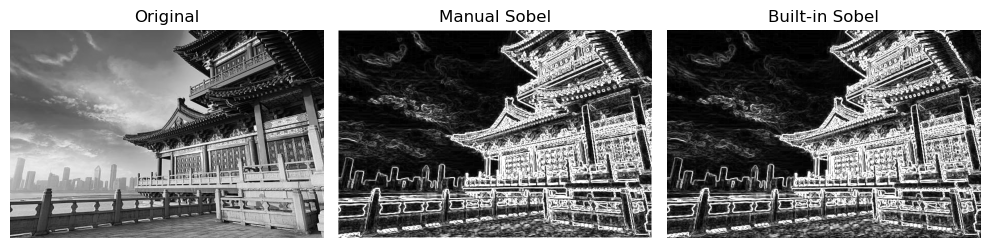

In [5]:
# Sobel Comparison
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(manual_sobel, cmap='gray')
plt.title("Manual Sobel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(builtin_sobel, cmap='gray')
plt.title("Built-in Sobel")
plt.axis("off")

plt.tight_layout()
plt.show()

# 6. Prewitt Operator
The Prewitt operator is another gradient-based edge detector. It uses fixed masks to approximate the first derivative in the horizontal and vertical directions.

Its magnitude is also computed as 
$$
G = \sqrt{G_x^2 + G_y^2}
$$


In [6]:
# Manual Prewitt

from streamlit import image


prewitt_x = np.array([[-1,0,1],
                      [-1,0,1],
                      [-1,0,1]])

prewitt_y = np.array([[-1,-1,-1],
                      [0,0,0],
                      [1,1,1]])

gx = convolve2d(img, prewitt_x, mode='same')
gy = convolve2d(img, prewitt_y, mode='same')

manual_prewitt = np.sqrt(gx**2 + gy**2)
manual_prewitt = np.uint8(np.clip(manual_prewitt,0,255))

# 7. Built-in Prewitt
The built-in Prewitt implementation is used to compare with the manually computed version.

In [7]:
# Built-in Prewitt

gx_cv = cv2.filter2D(img, cv2.CV_64F, prewitt_x)
gy_cv = cv2.filter2D(img, cv2.CV_64F, prewitt_y)

builtin_prewitt = cv2.magnitude(gx_cv, gy_cv)
builtin_prewitt = np.uint8(np.clip(builtin_prewitt,0,255))


# 8. Comparing Prewitt Results
The Prewitt outputs are displayed together to highlight the detected edges and compare the two implementations.

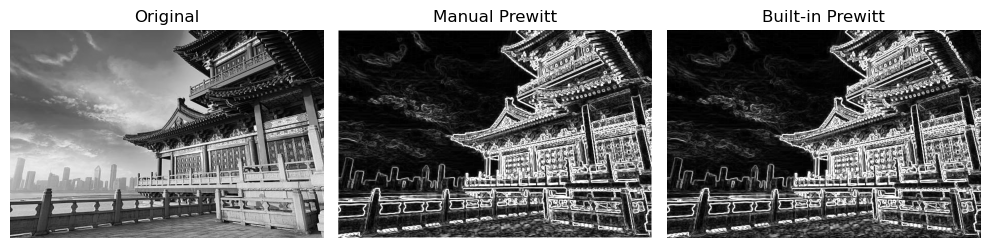

In [8]:

# Prewitt Comparison

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(manual_prewitt, cmap='gray')
plt.title("Manual Prewitt")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(builtin_prewitt, cmap='gray')
plt.title("Built-in Prewitt")
plt.axis("off")

plt.tight_layout()
plt.show()

# 9. Roberts Cross Operator
The Roberts Cross operator uses a small 2x2 kernel to detect diagonal edges by approximating the first derivative.

It computes the gradient magnitude as

$$
G = \sqrt{G_x^2 + G_y^2}
$$

In [9]:
# Manual Roberts Cross

roberts_x = np.array([[1,0],
                      [0,-1]])

roberts_y = np.array([[0,1],
                      [-1,0]])

gx = convolve2d(img, roberts_x, mode='same')
gy = convolve2d(img, roberts_y, mode='same')

manual_roberts = np.sqrt(gx**2 + gy**2)
manual_roberts = np.uint8(np.clip(manual_roberts,0,255))

# 10. Built-in Roberts


In [10]:
# Built-in Roberts

gx_cv = cv2.filter2D(img, cv2.CV_64F, roberts_x)
gy_cv = cv2.filter2D(img, cv2.CV_64F, roberts_y)

builtin_roberts = cv2.magnitude(gx_cv, gy_cv)
builtin_roberts = np.uint8(np.clip(builtin_roberts,0,255))

# 11. Roberts Comparison

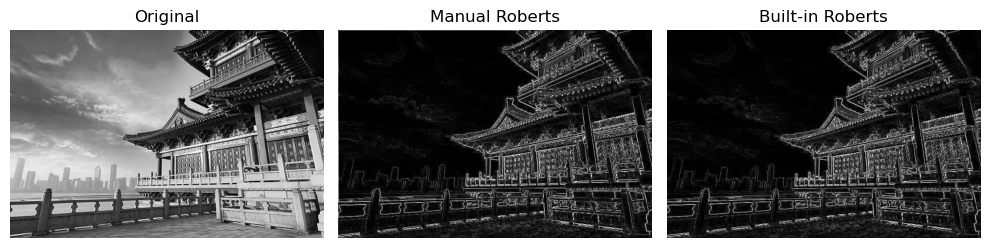

In [11]:
# Roberts Comparison

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(manual_roberts, cmap='gray')
plt.title("Manual Roberts")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(builtin_roberts, cmap='gray')
plt.title("Built-in Roberts")
plt.axis("off")

plt.tight_layout()
plt.show()

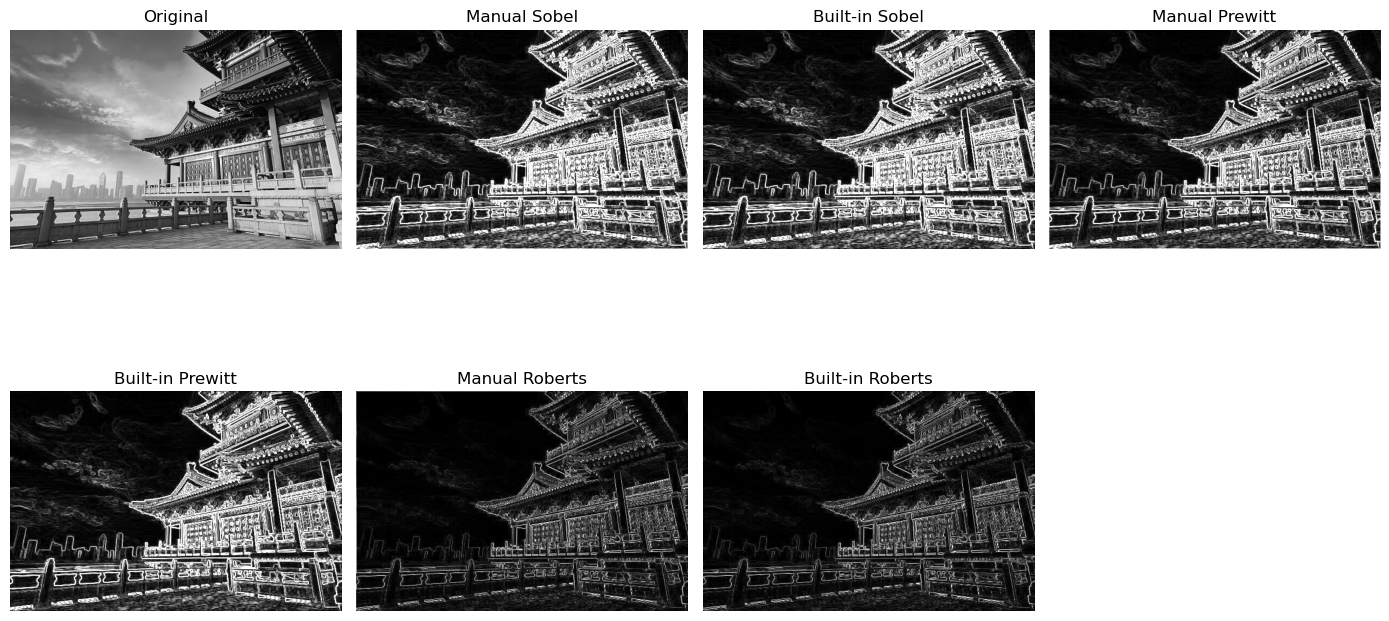

In [12]:
# Display Results

titles = [
    "Original",
    "Manual Sobel",
    "Built-in Sobel",
    "Manual Prewitt",
    "Built-in Prewitt",
    "Manual Roberts",
    "Built-in Roberts"
]

images = [
    img,
    manual_sobel,
    builtin_sobel,
    manual_prewitt,
    builtin_prewitt,
    manual_roberts,
    builtin_roberts
]

plt.figure(figsize=(14,8))

for i in range(len(images)):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()